# LOCATA Real-Data C-RSNN Demo (No Synthetic Pipeline)

This notebook trains a **Convolutional Recurrent Spiking Neural Network (C-RSNN)** on **real LOCATA multichannel recordings**.

Key upgrades over the previous MLP-SNN version:
- Spatial topology preserved via spiking `Conv2d` front-end.
- Stronger temporal modeling via recurrent spiking layer (RSNN).
- Acoustic prior added via **complex STFT + PHAT phase features** (instead of log-mel only).
- Auto dataset setup: first run downloads and extracts LOCATA dev set.

Task: multi-source DOA localization (2-3 active sources) with:
- BK8 condition (lab-grade 8-channel slice from real array recording)
- Robotized condition (4 active channels + low SNR + channel mismatch)

In [34]:
# Optional dependency install (uncomment if needed):
# %pip install -q torch torchaudio soundfile pandas matplotlib tqdm requests nbclient nbformat pyroomacoustics


In [35]:
import copy
import json
import math
import random
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm.auto import tqdm

try:
    import pyroomacoustics as pra
    PRA_AVAILABLE = True
except Exception as e:
    pra = None
    PRA_AVAILABLE = False
    print(f"pyroomacoustics import failed: {e}")


@dataclass
class ExpConfig:
    seed: int = 274
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Auto-download configuration
    data_root: str = "./data"
    locata_zip_url: str = "https://zenodo.org/records/3630471/files/dev.zip?download=1"
    locata_zip_name: str = "locata_dev.zip"
    locata_extract_dir: str = "LOCATA_dev"
    locata_root: str = "./data/LOCATA_dev/dev"

    # LOCATA subset
    array_name: str = "benchmark2"
    tasks: Tuple[int, ...] = (2, 4)

    # Frame sampling from required_time
    frame_stride: int = 4

    # Audio/feature
    sample_rate: int = 16000
    audio_secs: float = 1.0
    num_mics: int = 8

    n_fft: int = 512
    hop_length: int = 160
    win_length: int = 400
    n_freq_bins: int = 96
    target_frames: int = 48

    # Multi-source label settings
    doa_bins: int = 36
    min_sources: int = 2
    max_sources: int = 3

    # Real dataset sizes
    train_size: int = 1200
    val_size: int = 240
    test_size: int = 240

    # Simulated dataset sizes
    sim_train_size: int = 5000
    sim_snippet_bank_size: int = 3000

    # Three-stage curriculum (total=30)
    stage1_sim_epochs: int = 10
    stage2_mix_epochs: int = 10
    stage3_real_epochs: int = 10
    stage2_sim_ratio: float = 0.7

    # pyroomacoustics scene parameters
    sim_array_radius_m: float = 0.045
    sim_room_dim_min: Tuple[float, float, float] = (4.0, 4.0, 2.6)
    sim_room_dim_max: Tuple[float, float, float] = (8.0, 7.0, 3.5)
    sim_rt60_min: float = 0.2
    sim_rt60_max: float = 0.7
    sim_source_dist_min: float = 0.6
    sim_source_dist_max: float = 2.8
    sim_source_offset_max_s: float = 0.25
    sim_max_order: int = 10
    sim_snr_db_min: float = 10.0
    sim_snr_db_max: float = 25.0

    # C-RSNN architecture
    conv1_channels: int = 24
    conv2_channels: int = 32
    rnn_hidden: int = 256
    beta: float = 0.95
    threshold: float = 1.0

    batch_size: int = 32
    lr: float = 8e-4
    lambdas: Tuple[float, ...] = (0.0, 1e-4, 1e-3)
    count_loss_weight: float = 0.4

    # Robotized stress condition
    robot_active_mics: Tuple[int, ...] = (0, 2, 4, 6)
    robot_snr_db_min: float = 0.0
    robot_snr_db_max: float = 8.0
    robot_channel_jitter_db_std: float = 2.0

    results_json: str = "locata_crsnn_results.json"

    @property
    def num_samples(self) -> int:
        return int(self.sample_rate * self.audio_secs)

    @property
    def source_count_classes(self) -> int:
        return self.max_sources - self.min_sources + 1

    @property
    def total_epochs(self) -> int:
        return self.stage1_sim_epochs + self.stage2_mix_epochs + self.stage3_real_epochs


@dataclass
class RenderCondition:
    name: str
    robotize: bool = False
    add_noise: bool = False
    snr_db_min: float = 0.0
    snr_db_max: float = 0.0
    channel_jitter_db_std: float = 0.0


cfg = ExpConfig()
print(cfg)


ExpConfig(seed=274, device='cuda', data_root='./data', locata_zip_url='https://zenodo.org/records/3630471/files/dev.zip?download=1', locata_zip_name='locata_dev.zip', locata_extract_dir='LOCATA_dev', locata_root='./data/LOCATA_dev/dev', array_name='benchmark2', tasks=(2, 4), frame_stride=4, sample_rate=16000, audio_secs=1.0, num_mics=8, n_fft=512, hop_length=160, win_length=400, n_freq_bins=96, target_frames=48, doa_bins=36, min_sources=2, max_sources=3, train_size=1200, val_size=240, test_size=240, sim_train_size=5000, sim_snippet_bank_size=3000, stage1_sim_epochs=10, stage2_mix_epochs=10, stage3_real_epochs=10, stage2_sim_ratio=0.7, sim_array_radius_m=0.045, sim_room_dim_min=(4.0, 4.0, 2.6), sim_room_dim_max=(8.0, 7.0, 3.5), sim_rt60_min=0.2, sim_rt60_max=0.7, sim_source_dist_min=0.6, sim_source_dist_max=2.8, sim_source_offset_max_s=0.25, sim_max_order=10, sim_snr_db_min=10.0, sim_snr_db_max=25.0, conv1_channels=24, conv2_channels=32, rnn_hidden=256, beta=0.95, threshold=1.0, batch_s

In [36]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_locata_dev(cfg: ExpConfig) -> Path:
    root = Path(cfg.locata_root)
    if root.exists() and any(root.glob("task*")):
        print(f"LOCATA already available: {root}")
        return root

    data_root = Path(cfg.data_root)
    data_root.mkdir(parents=True, exist_ok=True)

    zip_path = data_root / cfg.locata_zip_name
    extract_root = data_root / cfg.locata_extract_dir
    extract_root.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists() or zip_path.stat().st_size < 1_000_000_000:
        print(f"Downloading LOCATA dev zip to {zip_path} ...")
        with requests.get(cfg.locata_zip_url, stream=True, timeout=60) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))
            with open(zip_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc="LOCATA dev.zip") as pbar:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))

    if not root.exists() or not any(root.glob("task*")):
        print(f"Extracting {zip_path} to {extract_root} ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_root)

    if not root.exists() or not any(root.glob("task*")):
        raise RuntimeError(f"LOCATA extraction failed: {root}")

    print(f"LOCATA ready: {root}")
    return root


_ = ensure_locata_dev(cfg)


LOCATA already available: data\LOCATA_dev\dev


In [37]:
def abs_seconds(row: pd.Series) -> float:
    return (
        ((float(row["day"]) * 24.0 + float(row["hour"])) * 60.0 + float(row["minute"])) * 60.0
        + float(row["second"])
    )


def wrap_to_pi(x: float) -> float:
    return (x + math.pi) % (2 * math.pi) - math.pi


def azimuth_to_bin(az_rad: float, num_bins: int) -> int:
    r = (az_rad + math.pi) / (2 * math.pi)
    idx = int(math.floor(r * num_bins))
    return max(0, min(num_bins - 1, idx))


def add_noise_for_snr(multich: torch.Tensor, snr_db: float) -> torch.Tensor:
    noise = torch.randn_like(multich)
    sig_pow = multich.pow(2).mean().clamp_min(1e-8)
    noi_pow = noise.pow(2).mean().clamp_min(1e-8)
    target_noi_pow = sig_pow / (10.0 ** (snr_db / 10.0))
    scale = torch.sqrt(target_noi_pow / noi_pow)
    return multich + scale * noise


def pad_or_trim(x: torch.Tensor, n: int) -> torch.Tensor:
    if x.shape[-1] == n:
        return x
    if x.shape[-1] > n:
        return x[..., :n]
    return F.pad(x, (0, n - x.shape[-1]))


def extract_spatial_phase_features(multich: torch.Tensor, cfg: ExpConfig) -> torch.Tensor:
    # multich: [C, N]
    window = torch.hann_window(cfg.win_length)
    stft = torch.stft(
        multich,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        win_length=cfg.win_length,
        window=window,
        return_complex=True,
    )
    # [C, F, T]
    stft = stft[:, :cfg.n_freq_bins, :]

    # Magnitude channel
    mag = torch.log1p(stft.abs())

    # PHAT-normalized cross-power against reference mic (mic0)
    ref = stft[0:1]
    cps = stft * torch.conj(ref)
    cps = cps / (cps.abs() + 1e-6)
    phat_re = cps.real
    phat_im = cps.imag

    # Stack features: [3, C, F, T]
    feat = torch.stack([mag, phat_re, phat_im], dim=0)

    # Resample time axis to target_frames
    t_now = feat.shape[-1]
    if t_now != cfg.target_frames:
        tmp = feat.reshape(1, -1, t_now)
        tmp = F.interpolate(tmp, size=cfg.target_frames, mode="linear", align_corners=False)
        feat = tmp.reshape(3, multich.shape[0], cfg.n_freq_bins, cfg.target_frames)

    # [T, 3, C, F]
    feat = feat.permute(3, 0, 1, 2).contiguous()

    # Per-sample normalization
    feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-6)
    return feat

In [38]:
class LocataRecording:
    def __init__(self, rec_dir: Path, array_name: str):
        self.rec_dir = rec_dir
        self.array_name = array_name
        self.array_dir = rec_dir / array_name

        audio_files = sorted(self.array_dir.glob("audio_array_*.wav"))
        ts_files = sorted(self.array_dir.glob("audio_array_timestamps_*.txt"))
        arr_pos_files = sorted(self.array_dir.glob("position_array_*.txt"))
        src_pos_files = sorted(self.array_dir.glob("position_source_*.txt"))

        if len(audio_files) != 1 or len(ts_files) != 1 or len(arr_pos_files) != 1 or len(src_pos_files) == 0:
            raise RuntimeError(f"Invalid LOCATA folder layout: {self.array_dir}")

        self.audio_path = audio_files[0]
        self.audio_ts_path = ts_files[0]
        self.arr_pos_path = arr_pos_files[0]
        self.req_time_path = self.array_dir / "required_time.txt"

        if not self.req_time_path.exists():
            raise RuntimeError(f"Missing required_time.txt in {self.array_dir}")

        self.req_df = pd.read_csv(self.req_time_path, sep="	")
        self.arr_df = pd.read_csv(self.arr_pos_path, sep="	")
        self.src_dfs = {
            p.stem.replace("position_source_", ""): pd.read_csv(p, sep="	")
            for p in src_pos_files
        }

        n = min(len(self.req_df), len(self.arr_df), *[len(df) for df in self.src_dfs.values()])
        self.req_df = self.req_df.iloc[:n].reset_index(drop=True)
        self.arr_df = self.arr_df.iloc[:n].reset_index(drop=True)
        for k in list(self.src_dfs.keys()):
            self.src_dfs[k] = self.src_dfs[k].iloc[:n].reset_index(drop=True)

        ts0 = pd.read_csv(self.audio_ts_path, sep="	", nrows=1).iloc[0]
        self.audio_t0 = abs_seconds(ts0)

        info = sf.info(str(self.audio_path))
        self.audio_sr = info.samplerate
        self.audio_frames = info.frames
        self.audio_channels = info.channels

    def center_sample_from_frame(self, frame_idx: int) -> int:
        t = abs_seconds(self.req_df.iloc[frame_idx])
        return int(round((t - self.audio_t0) * self.audio_sr))

    def source_bins_from_frame(self, frame_idx: int, num_bins: int) -> List[int]:
        arr_row = self.arr_df.iloc[frame_idx]
        ax, ay = float(arr_row["x"]), float(arr_row["y"])
        fvx, fvy = float(arr_row["ref_vec_x"]), float(arr_row["ref_vec_y"])
        front_ang = math.atan2(fvy, fvx)

        bins: List[int] = []
        for _, sdf in self.src_dfs.items():
            srow = sdf.iloc[frame_idx]
            if any(pd.isna(srow[k]) for k in ["x", "y", "z"]):
                continue

            sx, sy = float(srow["x"]), float(srow["y"])
            vx, vy = sx - ax, sy - ay
            if vx * vx + vy * vy < 1e-12:
                continue

            az_global = math.atan2(vy, vx)
            az_local = wrap_to_pi(az_global - front_ang)
            bins.append(azimuth_to_bin(az_local, num_bins))

        return sorted(set(bins))


def discover_locata_recordings(cfg: ExpConfig) -> Dict[str, LocataRecording]:
    root = Path(cfg.locata_root)
    recs: Dict[str, LocataRecording] = {}

    for task in cfg.tasks:
        task_dir = root / f"task{task}"
        if not task_dir.exists():
            continue
        for rec_dir in sorted(task_dir.glob("recording*")):
            arr_dir = rec_dir / cfg.array_name
            if not arr_dir.exists():
                continue
            key = f"task{task}/{rec_dir.name}/{cfg.array_name}"
            recs[key] = LocataRecording(rec_dir, cfg.array_name)

    if len(recs) == 0:
        raise RuntimeError("No valid LOCATA recordings found for selected tasks/array")
    return recs


def build_candidate_pool(
    recs: Dict[str, LocataRecording],
    cfg: ExpConfig,
    keys: Sequence[str],
) -> List[Tuple[str, int, Tuple[int, ...]]]:
    pool: List[Tuple[str, int, Tuple[int, ...]]] = []

    for key in keys:
        rec = recs[key]
        seg_len_native = int(round(cfg.audio_secs * rec.audio_sr))
        half = seg_len_native // 2

        for i in range(0, len(rec.req_df), cfg.frame_stride):
            if "valid_flag" in rec.req_df.columns and int(rec.req_df.iloc[i]["valid_flag"]) == 0:
                continue

            bins = rec.source_bins_from_frame(i, cfg.doa_bins)
            if not (cfg.min_sources <= len(bins) <= cfg.max_sources):
                continue

            center = rec.center_sample_from_frame(i)
            start = center - half
            stop = start + seg_len_native
            if start < 0 or stop > rec.audio_frames:
                continue

            if rec.audio_channels < cfg.num_mics:
                continue

            pool.append((key, i, tuple(bins)))

    if len(pool) == 0:
        raise RuntimeError("Candidate pool is empty. Adjust config or check dataset integrity.")
    return pool


def read_segment_8ch(rec: LocataRecording, frame_idx: int, cfg: ExpConfig) -> torch.Tensor:
    seg_len_native = int(round(cfg.audio_secs * rec.audio_sr))
    half = seg_len_native // 2
    center = rec.center_sample_from_frame(frame_idx)

    start = center - half
    stop = start + seg_len_native

    x_np, sr = sf.read(str(rec.audio_path), start=start, stop=stop, dtype="float32", always_2d=True)
    x = torch.from_numpy(x_np.T).float()
    x = x[:cfg.num_mics]

    if sr != cfg.sample_rate:
        x = torchaudio.functional.resample(x, sr, cfg.sample_rate)

    x = pad_or_trim(x, cfg.num_samples)
    return x


def apply_condition(x: torch.Tensor, cfg: ExpConfig, cond: RenderCondition) -> torch.Tensor:
    y = x.clone()

    if cond.robotize:
        mask = torch.zeros(y.shape[0], dtype=y.dtype)
        mask[list(cfg.robot_active_mics)] = 1.0
        y = y * mask.unsqueeze(1)

        if cond.channel_jitter_db_std > 0:
            jitter_db = torch.randn(y.shape[0]) * cond.channel_jitter_db_std
            gains = torch.pow(10.0, jitter_db / 20.0)
            y = y * gains.unsqueeze(1)

    if cond.add_noise:
        snr = random.uniform(cond.snr_db_min, cond.snr_db_max)
        y = add_noise_for_snr(y, snr)

    y = y / y.abs().max().clamp_min(1e-6)
    return y


def make_dataset_real(
    recs: Dict[str, LocataRecording],
    pool: Sequence[Tuple[str, int, Tuple[int, ...]]],
    n_items: int,
    cfg: ExpConfig,
    cond: RenderCondition,
) -> TensorDataset:
    xs, ys, ks = [], [], []

    for _ in tqdm(range(n_items), desc=f"Building {cond.name}-real"):
        ok = False
        for _try in range(50):
            key, frame_idx, bins = random.choice(pool)
            rec = recs[key]

            try:
                seg = read_segment_8ch(rec, frame_idx, cfg)
            except Exception:
                continue

            seg = apply_condition(seg, cfg, cond)
            feat = extract_spatial_phase_features(seg, cfg)

            y = torch.zeros(cfg.doa_bins, dtype=torch.float32)
            y[list(bins)] = 1.0

            xs.append(feat)
            ys.append(y)
            ks.append(len(bins))
            ok = True
            break

        if not ok:
            raise RuntimeError("Failed to sample valid real data after retries")

    x = torch.stack(xs).float()
    y = torch.stack(ys).float()
    k = torch.tensor(ks, dtype=torch.long)
    return TensorDataset(x, y, k)


def bin_to_azimuth_center(bin_idx: int, num_bins: int) -> float:
    return -math.pi + (float(bin_idx) + 0.5) * (2.0 * math.pi / float(num_bins))


def build_source_snippet_bank(
    recs: Dict[str, LocataRecording],
    pool: Sequence[Tuple[str, int, Tuple[int, ...]]],
    n_items: int,
    cfg: ExpConfig,
) -> List[torch.Tensor]:
    bank: List[torch.Tensor] = []

    for _ in tqdm(range(n_items), desc="Building snippet bank"):
        ok = False
        for _try in range(30):
            key, frame_idx, _ = random.choice(pool)
            rec = recs[key]
            try:
                seg = read_segment_8ch(rec, frame_idx, cfg)
            except Exception:
                continue

            mono = seg[0].clone()
            if mono.abs().mean().item() < 1e-4:
                continue

            mono = mono / mono.abs().max().clamp_min(1e-6)
            bank.append(mono.cpu())
            ok = True
            break

        if not ok:
            raise RuntimeError("Failed to build snippet bank")

    return bank


def _random_room_dim(cfg: ExpConfig) -> np.ndarray:
    return np.array(
        [
            random.uniform(cfg.sim_room_dim_min[0], cfg.sim_room_dim_max[0]),
            random.uniform(cfg.sim_room_dim_min[1], cfg.sim_room_dim_max[1]),
            random.uniform(cfg.sim_room_dim_min[2], cfg.sim_room_dim_max[2]),
        ],
        dtype=np.float32,
    )


def _circular_mic_positions(cfg: ExpConfig, center_xyz: np.ndarray) -> np.ndarray:
    angles = np.linspace(0.0, 2.0 * np.pi, cfg.num_mics, endpoint=False)
    x = center_xyz[0] + cfg.sim_array_radius_m * np.cos(angles)
    y = center_xyz[1] + cfg.sim_array_radius_m * np.sin(angles)
    z = np.full(cfg.num_mics, center_xyz[2], dtype=np.float32)
    return np.vstack([x, y, z])


def simulate_scene_pyroom(
    snippet_bank: Sequence[torch.Tensor],
    cfg: ExpConfig,
    bins: Optional[Sequence[int]] = None,
) -> Tuple[torch.Tensor, List[int]]:
    if not PRA_AVAILABLE:
        raise RuntimeError("pyroomacoustics is required but not installed.")

    for _ in range(8):
        try:
            if bins is None:
                k = random.randint(cfg.min_sources, cfg.max_sources)
                chosen_bins = sorted(random.sample(range(cfg.doa_bins), k))
            else:
                chosen_bins = sorted(set(int(b) for b in bins))

            room_dim = _random_room_dim(cfg)
            rt60 = random.uniform(cfg.sim_rt60_min, cfg.sim_rt60_max)
            absorption, max_order_rt = pra.inverse_sabine(rt60, room_dim.tolist())
            max_order = max(1, min(int(max_order_rt), cfg.sim_max_order))

            room = pra.ShoeBox(
                room_dim.tolist(),
                fs=cfg.sample_rate,
                materials=pra.Material(absorption),
                max_order=max_order,
            )

            center = np.array([room_dim[0] / 2.0, room_dim[1] / 2.0, 1.3], dtype=np.float32)
            mic_pos = _circular_mic_positions(cfg, center)
            room.add_microphone_array(mic_pos)

            offset_max = int(cfg.sim_source_offset_max_s * cfg.sample_rate)
            for b in chosen_bins:
                az = bin_to_azimuth_center(int(b), cfg.doa_bins)
                dist = random.uniform(cfg.sim_source_dist_min, cfg.sim_source_dist_max)

                sx = center[0] + dist * math.cos(az)
                sy = center[1] + dist * math.sin(az)
                sz = 1.4

                margin = 0.25
                sx = min(max(sx, margin), float(room_dim[0] - margin))
                sy = min(max(sy, margin), float(room_dim[1] - margin))
                sz = min(max(sz, margin), float(room_dim[2] - margin))

                sig = snippet_bank[random.randrange(len(snippet_bank))].numpy().astype(np.float32)
                if offset_max > 0:
                    offset = random.randint(0, offset_max)
                    if offset > 0:
                        sig = np.concatenate([np.zeros(offset, dtype=np.float32), sig], axis=0)

                room.add_source([sx, sy, sz], signal=sig)

            room.simulate()
            mix = torch.from_numpy(room.mic_array.signals[: cfg.num_mics]).float()
            mix = pad_or_trim(mix, cfg.num_samples)

            snr = random.uniform(cfg.sim_snr_db_min, cfg.sim_snr_db_max)
            mix = add_noise_for_snr(mix, snr)
            mix = mix / mix.abs().max().clamp_min(1e-6)
            return mix, chosen_bins
        except Exception:
            continue

    raise RuntimeError("pyroomacoustics scene simulation failed repeatedly")


def make_dataset_simulated(
    snippet_bank: Sequence[torch.Tensor],
    n_items: int,
    cfg: ExpConfig,
    cond: RenderCondition,
) -> TensorDataset:
    xs, ys, ks = [], [], []

    for _ in tqdm(range(n_items), desc=f"Building {cond.name}-sim"):
        ok = False
        for _try in range(20):
            try:
                seg, bins = simulate_scene_pyroom(snippet_bank, cfg)
            except Exception:
                continue

            seg = apply_condition(seg, cfg, cond)
            feat = extract_spatial_phase_features(seg, cfg)

            y = torch.zeros(cfg.doa_bins, dtype=torch.float32)
            y[list(bins)] = 1.0
            xs.append(feat)
            ys.append(y)
            ks.append(len(bins))
            ok = True
            break

        if not ok:
            raise RuntimeError("Failed to sample valid simulated data after retries")

    x = torch.stack(xs).float()
    y = torch.stack(ys).float()
    k = torch.tensor(ks, dtype=torch.long)
    return TensorDataset(x, y, k)


class MixedIndexDataset(Dataset):
    def __init__(self, real_ds: TensorDataset, sim_ds: TensorDataset, n_items: int, sim_ratio: float, seed: int):
        self.real_ds = real_ds
        self.sim_ds = sim_ds

        n_sim = int(round(n_items * sim_ratio))
        n_sim = min(max(n_sim, 0), n_items)
        n_real = n_items - n_sim

        rng = random.Random(seed)
        self.plan: List[Tuple[str, int]] = []
        for _ in range(n_sim):
            self.plan.append(("sim", rng.randrange(len(sim_ds))))
        for _ in range(n_real):
            self.plan.append(("real", rng.randrange(len(real_ds))))
        rng.shuffle(self.plan)

    def __len__(self) -> int:
        return len(self.plan)

    def __getitem__(self, idx: int):
        kind, j = self.plan[idx]
        if kind == "sim":
            return self.sim_ds[j]
        return self.real_ds[j]


In [39]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, u: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(u)
        return (u > 0).float()

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> torch.Tensor:
        (u,) = ctx.saved_tensors
        grad = 1.0 / (1.0 + u.abs()).pow(2)
        return grad_output * grad


spike_fn = SurrogateSpike.apply


def lif_step(cur: torch.Tensor, mem: torch.Tensor, beta: float, threshold: float):
    mem = beta * mem + cur
    spk = spike_fn(mem - threshold)
    mem = mem - spk * threshold
    return spk, mem


class CRSNN_DOA(nn.Module):
    def __init__(self, cfg: ExpConfig):
        super().__init__()
        self.cfg = cfg

        # Spatial front-end over [mic x freq]
        self.conv1 = nn.Conv2d(3, cfg.conv1_channels, kernel_size=(3, 5), padding=(1, 2), bias=False)
        self.conv2 = nn.Conv2d(cfg.conv1_channels, cfg.conv2_channels, kernel_size=(3, 5), padding=(1, 2), bias=False)

        # Determine flattened dim after pooling
        with torch.no_grad():
            dummy = torch.zeros(1, 3, cfg.num_mics, cfg.n_freq_bins)
            z1 = F.max_pool2d(self.conv1(dummy), kernel_size=(1, 2))
            z2 = F.max_pool2d(self.conv2(z1), kernel_size=(1, 2))
            flat_dim = z2.numel()

        self.flat_dim = flat_dim
        self.in_fc = nn.Linear(flat_dim, cfg.rnn_hidden, bias=False)
        self.rec_fc = nn.Linear(cfg.rnn_hidden, cfg.rnn_hidden, bias=False)

        self.readout_doa = nn.Linear(cfg.rnn_hidden, cfg.doa_bins, bias=True)
        self.readout_count = nn.Linear(cfg.rnn_hidden, cfg.source_count_classes, bias=True)
        self.time_gate = nn.Linear(cfg.rnn_hidden, 1, bias=True)

    def forward(self, x: torch.Tensor):
        # x: [B, T, 3, C, F]
        bsz, t_steps, _, _, _ = x.shape

        mem1 = None
        mem2 = None
        memr = x.new_zeros((bsz, self.cfg.rnn_hidden))
        spkr_prev = x.new_zeros((bsz, self.cfg.rnn_hidden))

        weighted_sum_doa = x.new_zeros((bsz, self.cfg.doa_bins))
        weighted_sum_count = x.new_zeros((bsz, self.cfg.source_count_classes))
        weight_sum = x.new_zeros((bsz, 1))

        total_spikes = x.new_zeros(())
        total_neurons = 0.0
        total_synops = x.new_zeros(())

        for t in range(t_steps):
            inp = x[:, t]  # [B, 3, C, F]

            cur1 = self.conv1(inp)
            if mem1 is None:
                mem1 = inp.new_zeros(cur1.shape)
            spk1, mem1 = lif_step(cur1, mem1, self.cfg.beta, self.cfg.threshold)
            spk1p = F.max_pool2d(spk1, kernel_size=(1, 2))

            cur2 = self.conv2(spk1p)
            if mem2 is None:
                mem2 = inp.new_zeros(cur2.shape)
            spk2, mem2 = lif_step(cur2, mem2, self.cfg.beta, self.cfg.threshold)
            spk2p = F.max_pool2d(spk2, kernel_size=(1, 2))

            flat = spk2p.flatten(1)

            cur_r = self.in_fc(flat) + self.rec_fc(spkr_prev)
            spkr, memr = lif_step(cur_r, memr, self.cfg.beta, self.cfg.threshold)
            spkr_prev = spkr

            logits_doa_t = self.readout_doa(spkr)
            logits_count_t = self.readout_count(spkr)
            gate_t = torch.sigmoid(self.time_gate(spkr))

            weighted_sum_doa += gate_t * logits_doa_t
            weighted_sum_count += gate_t * logits_count_t
            weight_sum += gate_t

            total_spikes += spk1.sum() + spk2.sum() + spkr.sum()
            total_neurons += float(spk1.numel() + spk2.numel() + spkr.numel())

            # SynOps proxy
            total_synops += (inp > 0).float().sum() * self.conv1.out_channels
            total_synops += spk1.sum() * self.conv2.out_channels
            total_synops += flat.sum() * self.in_fc.out_features
            total_synops += spkr.sum() * self.rec_fc.out_features
            total_synops += spkr.sum() * self.readout_doa.out_features
            total_synops += spkr.sum() * self.readout_count.out_features

        doa_logits = weighted_sum_doa / (weight_sum + 1e-6)
        count_logits = weighted_sum_count / (weight_sum + 1e-6)

        avg_fr = total_spikes / (total_neurons + 1e-8)
        spikes_per_sample = total_spikes / float(bsz)
        synops_per_sample = total_synops / float(bsz)

        stats = {
            "avg_fr": avg_fr,
            "spikes_per_sample": spikes_per_sample,
            "synops_per_sample": synops_per_sample,
        }
        return doa_logits, count_logits, stats



In [40]:
def decode_source_count(count_logits: torch.Tensor, cfg: ExpConfig) -> torch.Tensor:
    pred_idx = torch.argmax(count_logits, dim=1)
    return pred_idx + cfg.min_sources


def topk_prediction_mask(logits: torch.Tensor, pred_counts: torch.Tensor) -> torch.Tensor:
    pred = torch.zeros_like(logits)
    n_bins = logits.size(1)
    for i in range(logits.size(0)):
        k = int(pred_counts[i].item())
        k = max(1, min(k, n_bins))
        idx = torch.topk(logits[i], k).indices
        pred[i, idx] = 1.0
    return pred


def circular_bin_distance_deg(a: int, b: int, n_bins: int) -> float:
    d = abs(a - b)
    d = min(d, n_bins - d)
    return 360.0 * float(d) / float(n_bins)


def batch_angular_mae_deg(pred_mask: torch.Tensor, true_mask: torch.Tensor, n_bins: int) -> float:
    maes: List[float] = []
    for i in range(pred_mask.size(0)):
        pred_idx = torch.where(pred_mask[i] > 0.5)[0].tolist()
        true_idx = torch.where(true_mask[i] > 0.5)[0].tolist()
        if len(pred_idx) == 0 or len(true_idx) == 0:
            continue

        p_to_t = []
        for p in pred_idx:
            p_to_t.append(min(circular_bin_distance_deg(p, t, n_bins) for t in true_idx))

        t_to_p = []
        for t in true_idx:
            t_to_p.append(min(circular_bin_distance_deg(t, p, n_bins) for p in pred_idx))

        maes.append(0.5 * (sum(p_to_t) / len(p_to_t) + sum(t_to_p) / len(t_to_p)))

    if len(maes) == 0:
        return 180.0
    return float(sum(maes) / len(maes))


def run_epoch(model, loader, optimizer, lambda_fr: float, device: str, train: bool, cfg: ExpConfig) -> Dict[str, float]:
    bce = nn.BCEWithLogitsLoss()
    model.train() if train else model.eval()

    n = 0
    sum_loss = 0.0
    sum_doa_loss = 0.0
    sum_count_loss = 0.0
    sum_fr = 0.0
    sum_spikes = 0.0
    sum_synops = 0.0
    sum_count_acc = 0.0
    sum_mae_deg = 0.0

    tp = 0.0
    fp = 0.0
    fn = 0.0
    sum_exact = 0.0
    sum_topk = 0.0

    for xb, yb, kb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        kb = kb.to(device)

        bsz = xb.size(0)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            doa_logits, count_logits, stats = model(xb)

            doa_loss = bce(doa_logits, yb)
            count_target = (kb - cfg.min_sources).clamp(0, cfg.source_count_classes - 1)
            count_loss = F.cross_entropy(count_logits, count_target)
            loss = doa_loss + cfg.count_loss_weight * count_loss + lambda_fr * stats["avg_fr"]

            if train:
                loss.backward()
                optimizer.step()

        pred_k = decode_source_count(count_logits.detach(), cfg)
        pred = topk_prediction_mask(doa_logits.detach(), pred_k)

        tp += (pred * yb).sum().item()
        fp += (pred * (1.0 - yb)).sum().item()
        fn += ((1.0 - pred) * yb).sum().item()

        exact = (pred == yb).all(dim=1).float().mean().item()
        hit = ((pred * yb).sum(dim=1) / yb.sum(dim=1).clamp_min(1.0)).mean().item()
        count_acc = (pred_k == kb).float().mean().item()
        mae_deg = batch_angular_mae_deg(pred, yb, cfg.doa_bins)

        n += bsz
        sum_loss += loss.item() * bsz
        sum_doa_loss += doa_loss.item() * bsz
        sum_count_loss += count_loss.item() * bsz
        sum_fr += stats["avg_fr"].item() * bsz
        sum_spikes += stats["spikes_per_sample"].item() * bsz
        sum_synops += stats["synops_per_sample"].item() * bsz
        sum_exact += exact * bsz
        sum_topk += hit * bsz
        sum_count_acc += count_acc * bsz
        sum_mae_deg += mae_deg * bsz

    micro_f1 = (2.0 * tp) / (2.0 * tp + fp + fn + 1e-8)

    return {
        "loss": sum_loss / n,
        "doa_loss": sum_doa_loss / n,
        "count_loss": sum_count_loss / n,
        "micro_f1": micro_f1,
        "exact": sum_exact / n,
        "topk_hit": sum_topk / n,
        "topk_acc": sum_topk / n,
        "count_acc": sum_count_acc / n,
        "mae_deg": sum_mae_deg / n,
        "fr": sum_fr / n,
        "spikes": sum_spikes / n,
        "synops": sum_synops / n,
    }


def train_one_lambda(cfg: ExpConfig, lambda_fr: float, stage_plan, val_loader, test_loader_bk8, test_loader_robot):
    model = CRSNN_DOA(cfg).to(cfg.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    best_val = -1.0
    best_state = None
    history = []

    epoch_global = 0
    for stage_name, train_loader, stage_epochs in stage_plan:
        for _ in range(stage_epochs):
            epoch_global += 1
            tr = run_epoch(model, train_loader, optimizer, lambda_fr, cfg.device, train=True, cfg=cfg)
            va = run_epoch(model, val_loader, None, lambda_fr, cfg.device, train=False, cfg=cfg)

            history.append({"epoch": epoch_global, "stage": stage_name, "train": tr, "val": va})

            if va["micro_f1"] > best_val:
                best_val = va["micro_f1"]
                best_state = copy.deepcopy(model.state_dict())

            print(
                f"lambda={lambda_fr:.0e} | stage={stage_name:<10s} | epoch {epoch_global:02d}/{cfg.total_epochs:02d} | "
                f"val_hit={va['topk_hit']:.3f}, val_f1={va['micro_f1']:.3f}, "
                f"val_cnt={va['count_acc']:.3f}, val_mae={va['mae_deg']:.1f}deg, val_fr={va['fr']:.5f}"
            )

    model.load_state_dict(best_state)
    test_bk8 = run_epoch(model, test_loader_bk8, None, lambda_fr, cfg.device, train=False, cfg=cfg)
    test_robot = run_epoch(model, test_loader_robot, None, lambda_fr, cfg.device, train=False, cfg=cfg)

    return {
        "lambda": lambda_fr,
        "best_val_f1": best_val,
        "test_bk8": test_bk8,
        "test_robot": test_robot,
        "history": history,
    }


In [41]:
set_seed(cfg.seed)

if not PRA_AVAILABLE:
    raise RuntimeError("pyroomacoustics is required for 70/30 sim-real curriculum. Install it and rerun.")

recs = discover_locata_recordings(cfg)
all_keys = sorted(recs.keys())
print("Found recordings:")
for k in all_keys:
    r = recs[k]
    print(f"  {k} | channels={r.audio_channels}, fs={r.audio_sr}, frames={r.audio_frames}, sources={len(r.src_dfs)}")

rng = random.Random(cfg.seed)
keys = all_keys.copy()
rng.shuffle(keys)

n_train = max(3, int(0.6 * len(keys)))
n_val = max(1, int(0.2 * len(keys)))
train_keys = keys[:n_train]
val_keys = keys[n_train:n_train + n_val]
test_keys = keys[n_train + n_val:]
if len(test_keys) == 0:
    test_keys = val_keys[-1:]

print("Split:")
print(" train:", train_keys)
print(" val:  ", val_keys)
print(" test: ", test_keys)

train_pool = build_candidate_pool(recs, cfg, train_keys)
val_pool = build_candidate_pool(recs, cfg, val_keys)
test_pool = build_candidate_pool(recs, cfg, test_keys)
print(f"Candidate counts: train={len(train_pool)}, val={len(val_pool)}, test={len(test_pool)}")

cond_bk8 = RenderCondition(name="bk8", robotize=False, add_noise=False)
cond_robot = RenderCondition(
    name="robot4",
    robotize=True,
    add_noise=True,
    snr_db_min=cfg.robot_snr_db_min,
    snr_db_max=cfg.robot_snr_db_max,
    channel_jitter_db_std=cfg.robot_channel_jitter_db_std,
)

train_real_ds = make_dataset_real(recs, train_pool, cfg.train_size, cfg, cond_bk8)
val_ds = make_dataset_real(recs, val_pool, cfg.val_size, cfg, cond_bk8)
test_bk8_ds = make_dataset_real(recs, test_pool, cfg.test_size, cfg, cond_bk8)
test_robot_ds = make_dataset_real(recs, test_pool, cfg.test_size, cfg, cond_robot)

snippet_bank = build_source_snippet_bank(recs, train_pool, cfg.sim_snippet_bank_size, cfg)
sim_train_ds = make_dataset_simulated(snippet_bank, cfg.sim_train_size, cfg, cond_bk8)
mix_train_ds = MixedIndexDataset(train_real_ds, sim_train_ds, cfg.train_size, cfg.stage2_sim_ratio, cfg.seed)

print(f"Real train samples: {len(train_real_ds)}")
print(f"Sim train samples: {len(sim_train_ds)}")
print(f"Mix train samples: {len(mix_train_ds)} (sim ratio={cfg.stage2_sim_ratio:.2f})")

val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
test_bk8_loader = DataLoader(test_bk8_ds, batch_size=cfg.batch_size, shuffle=False)
test_robot_loader = DataLoader(test_robot_ds, batch_size=cfg.batch_size, shuffle=False)

stage_plan = [
    ("sim_pre", DataLoader(sim_train_ds, batch_size=cfg.batch_size, shuffle=True), cfg.stage1_sim_epochs),
    ("mix_70_30", DataLoader(mix_train_ds, batch_size=cfg.batch_size, shuffle=True), cfg.stage2_mix_epochs),
    ("real_ft", DataLoader(train_real_ds, batch_size=cfg.batch_size, shuffle=True), cfg.stage3_real_epochs),
]
stage_plan = [(name, loader, ep) for (name, loader, ep) in stage_plan if ep > 0]

print("Stage plan:")
for name, _, ep in stage_plan:
    print(f"  {name}: {ep} epochs")
print(f"Total epochs: {sum(ep for _, _, ep in stage_plan)}")

x0, y0, k0 = train_real_ds[0]
print("Input shape:", tuple(x0.shape), "(T, FeatType, Mic, Freq)")
print("Label active bins:", int(y0.sum().item()), "k:", int(k0.item()))
print("Source count classes:", cfg.source_count_classes)
print("Device:", cfg.device)

results = []
for lam in cfg.lambdas:
    set_seed(cfg.seed)
    print()
    print("=" * 80)
    print(f"Training with lambda={lam}")
    out = train_one_lambda(cfg, lam, stage_plan, val_loader, test_bk8_loader, test_robot_loader)
    results.append(out)

summary = []
print()
print("Final summary:")
for r in results:
    a = r["test_bk8"]
    b = r["test_robot"]
    row = {
        "lambda": r["lambda"],
        "bk8_hit": a["topk_hit"],
        "bk8_f1": a["micro_f1"],
        "bk8_count_acc": a["count_acc"],
        "bk8_mae_deg": a["mae_deg"],
        "bk8_fr": a["fr"],
        "robot_hit": b["topk_hit"],
        "robot_f1": b["micro_f1"],
        "robot_count_acc": b["count_acc"],
        "robot_mae_deg": b["mae_deg"],
        "robot_fr": b["fr"],
        "robot_synops": b["synops"],
    }
    summary.append(row)
    print(
        f"lambda={r['lambda']:.0e} | "
        f"BK8 hit={a['topk_hit']:.3f}, f1={a['micro_f1']:.3f}, cnt={a['count_acc']:.3f}, mae={a['mae_deg']:.1f}deg, FR={a['fr']:.5f} | "
        f"Robot hit={b['topk_hit']:.3f}, f1={b['micro_f1']:.3f}, cnt={b['count_acc']:.3f}, mae={b['mae_deg']:.1f}deg, FR={b['fr']:.5f}"
    )

with open(cfg.results_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary to: {cfg.results_json}")


Found recordings:
  task2/recording1/benchmark2 | channels=12, fs=48000, frames=302528, sources=2
  task2/recording3/benchmark2 | channels=12, fs=48000, frames=298432, sources=3
  task4/recording1/benchmark2 | channels=12, fs=48000, frames=2867119, sources=2
  task4/recording2/benchmark2 | channels=12, fs=48000, frames=3006464, sources=2
  task4/recording3/benchmark2 | channels=12, fs=48000, frames=2891776, sources=2
Split:
 train: ['task2/recording1/benchmark2', 'task4/recording1/benchmark2', 'task4/recording3/benchmark2']
 val:   ['task4/recording2/benchmark2']
 test:  ['task2/recording3/benchmark2']
Candidate counts: train=3588, val=1824, test=156


Building bk8-real:   0%|          | 0/1200 [00:00<?, ?it/s]

Building bk8-real:   0%|          | 0/240 [00:00<?, ?it/s]

Building bk8-real:   0%|          | 0/240 [00:00<?, ?it/s]

Building robot4-real:   0%|          | 0/240 [00:00<?, ?it/s]

Building snippet bank:   0%|          | 0/3000 [00:00<?, ?it/s]

Building bk8-sim:   0%|          | 0/5000 [00:00<?, ?it/s]

Real train samples: 1200
Sim train samples: 5000
Mix train samples: 1200 (sim ratio=0.70)
Stage plan:
  sim_pre: 10 epochs
  mix_70_30: 10 epochs
  real_ft: 10 epochs
Total epochs: 30
Input shape: (48, 3, 8, 96) (T, FeatType, Mic, Freq)
Label active bins: 2 k: 2
Source count classes: 2
Device: cuda

Training with lambda=0.0
lambda=0e+00 | stage=sim_pre    | epoch 01/30 | val_hit=0.071, val_f1=0.057, val_cnt=0.000, val_mae=31.7deg, val_fr=0.16707
lambda=0e+00 | stage=sim_pre    | epoch 02/30 | val_hit=0.008, val_f1=0.008, val_cnt=1.000, val_mae=111.7deg, val_fr=0.09065
lambda=0e+00 | stage=sim_pre    | epoch 03/30 | val_hit=0.000, val_f1=0.000, val_cnt=0.350, val_mae=70.1deg, val_fr=0.04531
lambda=0e+00 | stage=sim_pre    | epoch 04/30 | val_hit=0.121, val_f1=0.114, val_cnt=0.758, val_mae=46.7deg, val_fr=0.02288
lambda=0e+00 | stage=sim_pre    | epoch 05/30 | val_hit=0.081, val_f1=0.075, val_cnt=0.646, val_mae=55.7deg, val_fr=0.04692
lambda=0e+00 | stage=sim_pre    | epoch 06/30 | val_h

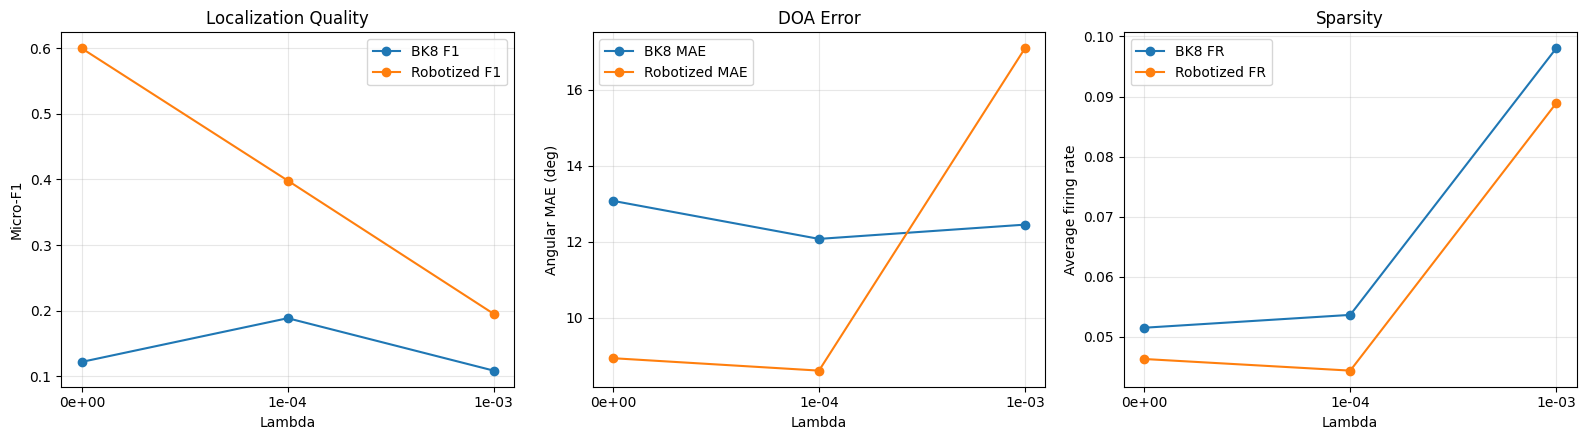

In [42]:
lambdas = [r["lambda"] for r in results]
labels = [f"{lam:.0e}" for lam in lambdas]

bk8_f1 = [r["test_bk8"]["micro_f1"] for r in results]
robot_f1 = [r["test_robot"]["micro_f1"] for r in results]

bk8_mae = [r["test_bk8"]["mae_deg"] for r in results]
robot_mae = [r["test_robot"]["mae_deg"] for r in results]

bk8_fr = [r["test_bk8"]["fr"] for r in results]
robot_fr = [r["test_robot"]["fr"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = list(range(len(lambdas)))

axes[0].plot(x, bk8_f1, "o-", label="BK8 F1")
axes[0].plot(x, robot_f1, "o-", label="Robotized F1")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Micro-F1")
axes[0].set_title("Localization Quality")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, bk8_mae, "o-", label="BK8 MAE")
axes[1].plot(x, robot_mae, "o-", label="Robotized MAE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Angular MAE (deg)")
axes[1].set_title("DOA Error")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(x, bk8_fr, "o-", label="BK8 FR")
axes[2].plot(x, robot_fr, "o-", label="Robotized FR")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel("Lambda")
axes[2].set_ylabel("Average firing rate")
axes[2].set_title("Sparsity")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()



## Implementation Notes

- No synthetic dataset path exists in this notebook.
- Data path is real LOCATA recordings only.
- Download/extract is automated in the early setup cell.
- Architecture is upgraded to C-RSNN to preserve spatial structure and temporal dynamics.